In [2]:
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard
import os


In [3]:
img_rows, img_cols = 224, 224

MobileNet = MobileNet(weights='imagenet', include_top=False, input_shape=(img_rows, img_cols, 3))



In [4]:
log_dir = os.path.join("logs", "emotion_detection")

In [5]:
for layer in MobileNet.layers:
    layer.trainable = True

# Opcional: ver capas
for i, layer in enumerate(MobileNet.layers):
    print(str(i), layer.__class__.__name__, layer.trainable)


0 InputLayer True
1 Conv2D True
2 BatchNormalization True
3 ReLU True
4 DepthwiseConv2D True
5 BatchNormalization True
6 ReLU True
7 Conv2D True
8 BatchNormalization True
9 ReLU True
10 ZeroPadding2D True
11 DepthwiseConv2D True
12 BatchNormalization True
13 ReLU True
14 Conv2D True
15 BatchNormalization True
16 ReLU True
17 DepthwiseConv2D True
18 BatchNormalization True
19 ReLU True
20 Conv2D True
21 BatchNormalization True
22 ReLU True
23 ZeroPadding2D True
24 DepthwiseConv2D True
25 BatchNormalization True
26 ReLU True
27 Conv2D True
28 BatchNormalization True
29 ReLU True
30 DepthwiseConv2D True
31 BatchNormalization True
32 ReLU True
33 Conv2D True
34 BatchNormalization True
35 ReLU True
36 ZeroPadding2D True
37 DepthwiseConv2D True
38 BatchNormalization True
39 ReLU True
40 Conv2D True
41 BatchNormalization True
42 ReLU True
43 DepthwiseConv2D True
44 BatchNormalization True
45 ReLU True
46 Conv2D True
47 BatchNormalization True
48 ReLU True
49 DepthwiseConv2D True
50 BatchNorma

In [6]:
def addTopModelMobileNet(bottom_model, num_classes):
    top_model = bottom_model.output
    top_model = GlobalAveragePooling2D()(top_model)

    top_model = Dense(4096, activation='relu')(top_model)
    top_model = Dropout(0.5)(top_model)

    top_model = Dense(2048, activation='relu')(top_model)
    top_model = Dropout(0.5)(top_model)

    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dropout(0.5)(top_model)

    top_model = Dense(512, activation='relu')(top_model)
    top_model = Dropout(0.3)(top_model)

    top_model = Dense(num_classes, activation='softmax')(top_model)

    return top_model

In [7]:
num_classes = 7
FC_Head = addTopModelMobileNet(MobileNet, num_classes)
model = Model(inputs=MobileNet.input, outputs=FC_Head)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 18,444,487 (70.36 MB)

 Trainable params: 18,422,599 (70.28 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [8]:
train_data_dir = r'D:\entremiento_mobilnet_pruebas\fer2013\train'
validation_data_dir = r'D:\entremiento_mobilnet_pruebas\fer2013\test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical'
)

print("Clases detectadas:", train_generator.class_indices)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Clases detectadas: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [9]:
checkpoint = ModelCheckpoint('emotion_face_mobilNet.h5', monitor='val_loss', mode='min', save_best_only=True, verbose=1)

earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=1, restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=5, verbose=1, factor=0.2, min_lr=0.0001)

tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

callbacks = [tensorboard_callback, earlystop, checkpoint, learning_rate_reduction]

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])



In [10]:
nb_train_samples = train_generator.samples
nb_validation_samples = validation_generator.samples
epochs = 50

history = model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size,
    verbose=1  
)

c:\Users\jharo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.2956 - loss: 1.8489

c:\Users\jharo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 1.44771, saving model to emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 910s 1s/step - accuracy: 0.2956 - loss: 1.8487 - val_accuracy: 0.4301 - val_loss: 1.4477 - learning_rate: 0.0010
Epoch 2/50
  1/897 ━━━━━━━━━━━━━━━━━━━━ 9:33 640ms/step - accuracy: 0.4375 - loss: 1.3828

...

897/897 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.7188 - loss: 0.6807 - val_accuracy: 0.6722 - val_loss: 0.8966 - learning_rate: 2.0000e-04
Epoch 41/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6981 - loss: 0.8271
Epoch 41: val_loss did not improve from 0.89657
897/897 ━━━━━━━━━━━━━━━━━━━━ 1159s 1s/step - accuracy: 0.6981 - loss: 0.8271 - val_accuracy: 0.6709 - val_loss: 0.9004 - learning_rate: 2.0000e-04
Epoch 42/50
  1/897 ━━━━━━━━━━━━━━━━━━━━ 9:10 614ms/step - accuracy: 0.6875 - loss: 0.8537
Epoch 42: val_loss did not improve from 0.89657
897/897 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.6875 - loss: 0.8537 - val_accuracy: 0.6699 - val_loss: 0.9004 - learning_rate: 2.0000e-04
Epoch 43/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.7045 - loss: 0.7948
Epoch 43: val_loss improved from 0.89657 to 0.89613, saving model to emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 627s 699ms/step - accuracy: 0.7045 - loss: 0.7948 - val_accuracy: 0.6702 - val_loss: 0.8961 - learning_rate: 2.0000e-04
Epoch 44/50
  1/897 ━━━━━━━━━━━━━━━━━━━━ 10:28 701ms/step - accuracy: 0.7812 - loss: 0.6925
Epoch 44: val_loss did not improve from 0.89613
897/897 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.7812 - loss: 0.6925 - val_accuracy: 0.6701 - val_loss: 0.8964 - learning_rate: 2.0000e-04
Epoch 45/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.7052 - loss: 0.8008
Epoch 45: val_loss improved from 0.89613 to 0.89581, saving model to emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 803s 895ms/step - accuracy: 0.7052 - loss: 0.8008 - val_accuracy: 0.6738 - val_loss: 0.8958 - learning_rate: 2.0000e-04
Epoch 46/50
  1/897 ━━━━━━━━━━━━━━━━━━━━ 27:37 2s/step - accuracy: 0.7812 - loss: 0.5288
Epoch 46: val_loss did not improve from 0.89581
897/897 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - accuracy: 0.7812 - loss: 0.5288 - val_accuracy: 0.6741 - val_loss: 0.8968 - learning_rate: 2.0000e-04
Epoch 47/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.7170 - loss: 0.7842
Epoch 47: val_loss improved from 0.89581 to 0.89010, saving model to emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 859s 958ms/step - accuracy: 0.7170 - loss: 0.7842 - val_accuracy: 0.6762 - val_loss: 0.8901 - learning_rate: 2.0000e-04
Epoch 48/50
  1/897 ━━━━━━━━━━━━━━━━━━━━ 8:57 600ms/step - accuracy: 0.7500 - loss: 0.5713
Epoch 48: val_loss improved from 0.89010 to 0.88989, saving model to emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7500 - loss: 0.5713 - val_accuracy: 0.6773 - val_loss: 0.8899 - learning_rate: 2.0000e-04
Epoch 49/50
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.7199 - loss: 0.7644
Epoch 49: val_loss did not improve from 0.88989
897/897 ━━━━━━━━━━━━━━━━━━━━ 640s 713ms/step - accuracy: 0.7199 - loss: 0.7644 - val_accuracy: 0.6773 - val_loss: 0.8983 - learning_rate: 2.0000e-04
Epoch 50/50
  1/897 ━━━━━━━━━━━━━━━━━━━━ 9:14 619ms/step - accuracy: 0.6250 - loss: 0.8669
Epoch 50: val_loss did not improve from 0.88989
897/897 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.6250 - loss: 0.8669 - val_accuracy: 0.6762 - val_loss: 0.8987 - learning_rate: 2.0000e-04
Restoring model weights from the end of the best epoch: 48.


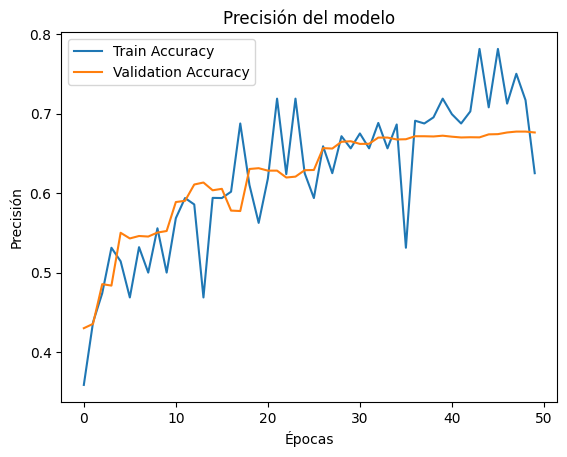

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Precisión del modelo")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.show()

In [12]:
model.save("modelo_final.h5")



Found 7178 images belonging to 7 classes.


c:\Users\jharo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 50s 220ms/step


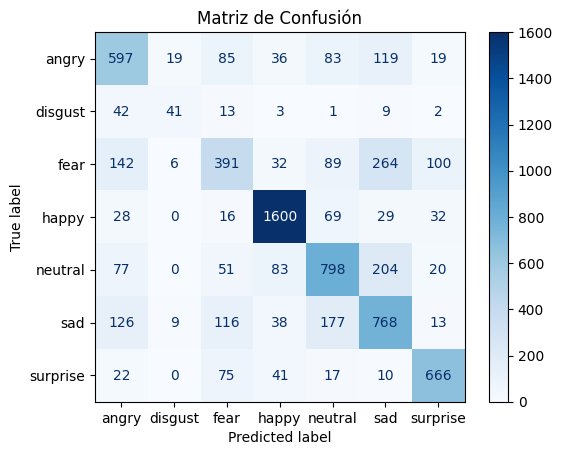

In [3]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Cargar el modelo previamente entrenado
model = load_model("emotion_face_mobilNet.h5")

# Directorio del conjunto de validación
validation_data_dir = r'D:\\entremiento_mobilnet_pruebas\\fer2013\\test'

# Preparar el generador de datos de validación
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # IMPORTANTE para que las predicciones coincidan con las etiquetas reales
)

# Hacer predicciones
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Obtener las etiquetas reales
y_true = validation_generator.classes

# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=validation_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()


Found 7178 images belonging to 7 classes.


c:\Users\jharo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step


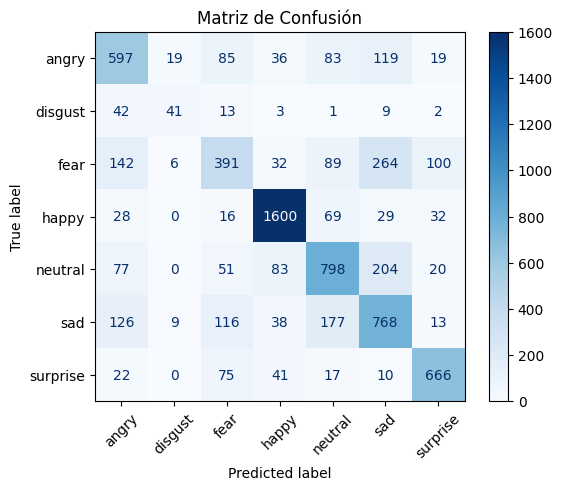

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

       angry       0.58      0.62      0.60       958
     disgust       0.55      0.37      0.44       111
        fear       0.52      0.38      0.44      1024
       happy       0.87      0.90      0.89      1774
     neutral       0.65      0.65      0.65      1233
         sad       0.55      0.62      0.58      1247
    surprise       0.78      0.80      0.79       831

    accuracy                           0.68      7178
   macro avg       0.64      0.62      0.63      7178
weighted avg       0.67      0.68      0.67      7178

Accuracy general: 67.72%


In [4]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Cargar el modelo previamente entrenado
model = load_model("emotion_face_mobilNet.h5")

# Directorio del conjunto de validación
validation_data_dir = r'D:\\entremiento_mobilnet_pruebas\\fer2013\\test'

# Preparar el generador de datos de validación
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Hacer predicciones
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Obtener las etiquetas reales
y_true = validation_generator.classes
labels = list(validation_generator.class_indices.keys())

# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Matriz de Confusión")
plt.show()

# Calcular métricas detalladas
print("=== Reporte de Clasificación ===")
report = classification_report(y_true, y_pred, target_names=labels)
print(report)

# Calcular accuracy general
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy general: {accuracy * 100:.2f}%")
